In [ ]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9777777777777777

In [1]:
import pandas as pd

data = pd.read_excel("iris.xlsx")
data.to_csv("iris.csv", index=False)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("iris.csv")

# Features and target
X = data.drop("species", axis=1)
y = data["species"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- Linear Kernel --------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear Kernel Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))


# -------- RBF Kernel --------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF Kernel Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 1.0
Linear Kernel Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
RBF Kernel Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [3]:
import pandas as pd

data = pd.read_excel("letter-recognition.xlsx")
data.to_csv("letter-recognition.csv", index=False)

Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0 

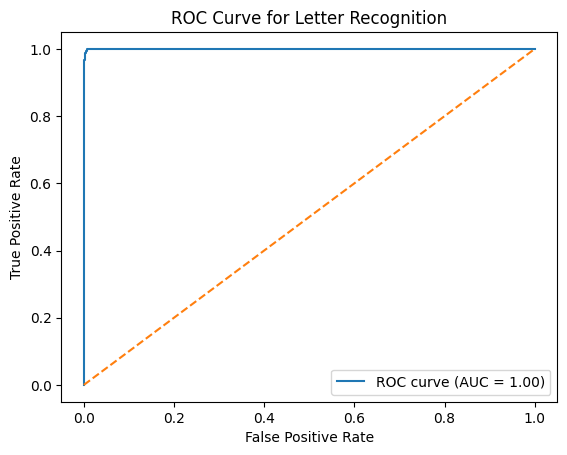

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
data = pd.read_csv("letter-recognition.csv")

# Features and target
X = data.iloc[:,1:]      # all columns except first
y = data.iloc[:,0]       # first column (letter label)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM model
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


# ----- ROC Curve and AUC -----

# Convert labels to binary for multiclass ROC
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# One-vs-Rest classifier
ovr = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
ovr.fit(X_train, y_train)

y_score = ovr.predict_proba(X_test)

# ROC for first class (example)
fpr, tpr, _ = roc_curve(y_test_bin[:,0], y_score[:,0])
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Letter Recognition")
plt.legend()
plt.show()

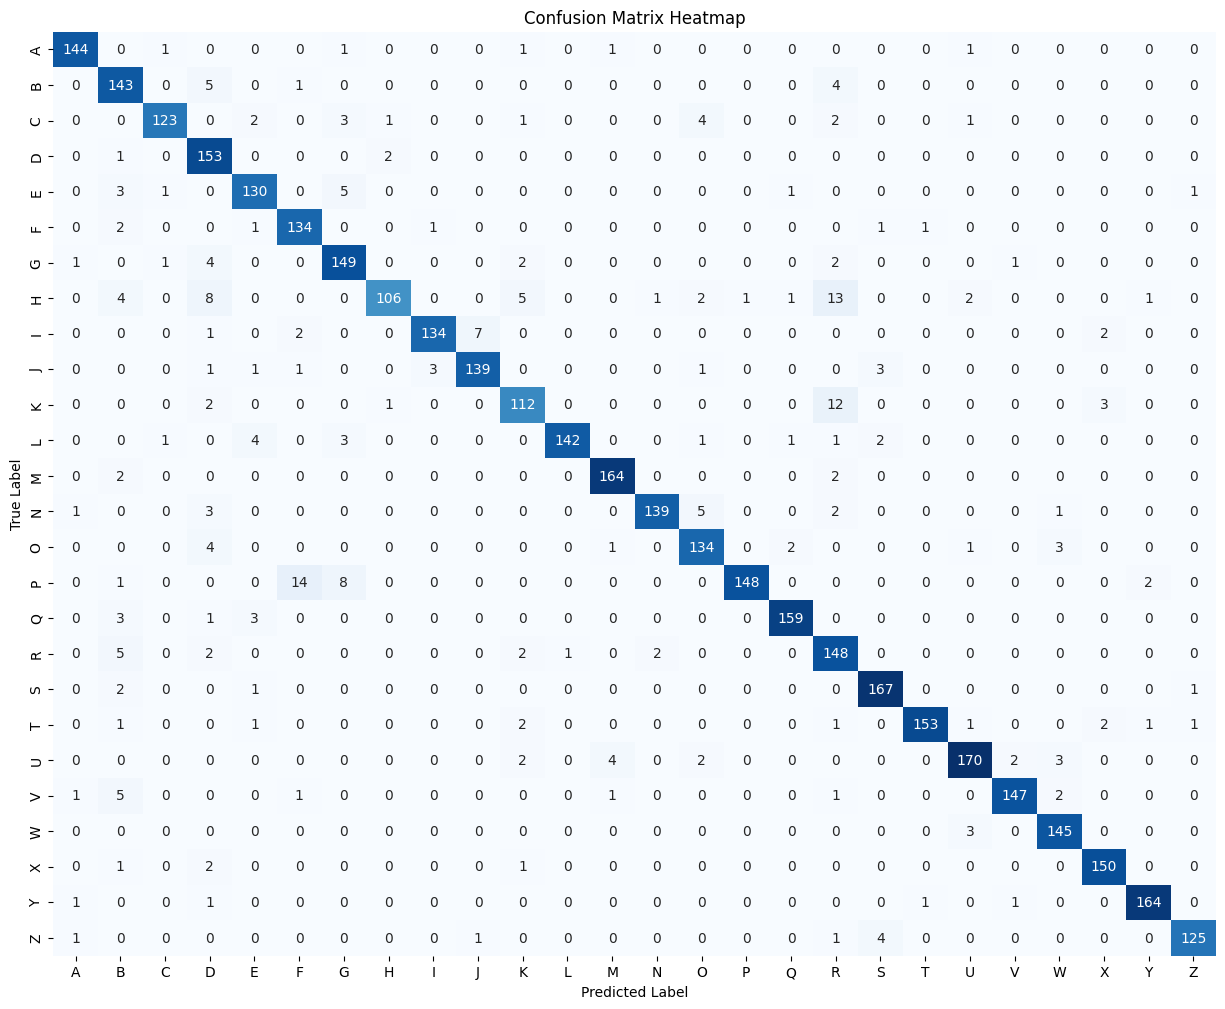

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()